# Analytical Gyrokinetic Benchmarks

Standard analytical test cases for gyrokinetic codes, following GKW benchmarks (Chapter 11 of the manual).

| Test | Physics | Analytical prediction | Status |
|------|---------|----------------------|--------|
| **Rosenbluth-Hinton** | Zonal flow residual | $\phi(\infty)/\phi(0) = 1/(1+q^2\Theta/\varepsilon^2)$ | 0.1% match at $t>80$ |
| **CBC Linear ITG** | Growth rate vs $k_\theta\rho_s$ | GKW/GS2 reference | qualitative match |

In [24]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), ".."))


os.environ["CUDA_VISIBLE_DEVICES"] = "7"

In [36]:
import time as _time
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from dataclasses import replace

from gyaradax.geometry import compute_geometry, compute_geometry_from_input
from gyaradax.params import gkparams_from_input_and_geometry, GKParams
from gyaradax.simulate import gk_run
from gyaradax.solver import init_f, default_state, linear_precompute
from gyaradax.integrals import calculate_phi
from gyaradax.plot_utils import JAX_COLORS

GKW_BENCHMARKS = os.path.join("..", "gkw_ref", "benchmarks")
os.makedirs("figs", exist_ok=True)

---
## 1. Rosenbluth-Hinton Zonal Flow Test

An initial radial density perturbation (ky=0) excites a geo-acoustic mode (GAM) that oscillates and decays, leaving a residual zonal potential:

$$\frac{\phi(t=\infty)}{\phi(t=0)} = \frac{1}{1 + q^2 \Theta / \varepsilon^2}, \qquad \Theta = 1.6\,\varepsilon^{3/2} + 0.5\,\varepsilon^2 + 0.36\,\varepsilon^{5/2}$$

Parameters from GKW benchmark (`gkw_ref/benchmarks/zonal_flow/zonal01/input.dat`):
$q = 1.3$, $\varepsilon = 0.05$, $\hat{s} = 0.1592$, $k_\psi\rho_s \approx 0.025$, `disp_par=0.01`,
electrostatic, collisionless, adiabatic electrons.

Reference: Hinton & Rosenbluth, PRL 80 (1998); Xiao & Catto, PoP 13 (2006).

In [26]:
# analytical residual
def rh_residual_xiao_catto(q, eps):
    """Xiao-Catto formula for the RH zonal flow residual (PoP 13, 2006)."""
    theta = 1.6 * eps**1.5 + 0.5 * eps**2 + 0.36 * eps**2.5
    return 1.0 / (1.0 + q**2 * theta / eps**2)

def rh_residual_hinton(q, eps):
    """Original Hinton-Rosenbluth lowest-order formula (PRL 80, 1998)."""
    return 1.0 / (1.0 + 1.6 * q**2 / eps**0.5)

q_rh, eps_rh = 1.3, 0.05
print(f"RH residual (Xiao-Catto): {rh_residual_xiao_catto(q_rh, eps_rh):.4f}")
print(f"RH residual (Hinton):     {rh_residual_hinton(q_rh, eps_rh):.4f}")
print(f"GKW result:               0.0713")

RH residual (Xiao-Catto): 0.0711
RH residual (Hinton):     0.0764
GKW result:               0.0713


In [27]:
# Build geometry from the GKW benchmark input.dat (zonal01)
# This uses the EXACT GKW parameters: q=1.3, shat=0.1592, eps=0.05,
# krhomax=0.025, ikxspace=1, disp_par=0.01

GKW_BENCHMARKS = os.path.join("..", "gkw_ref", "benchmarks")
zonal01_input = os.path.join(GKW_BENCHMARKS, "zonal_flow", "zonal01", "input.dat")

from gyaradax.params import gkparams_from_input_and_geometry

rh_geom = compute_geometry_from_input(zonal01_input)
rh_params = gkparams_from_input_and_geometry(zonal01_input, rh_geom)
# non_linear=False + large naverage → linear mode without per-ky normalization
rh_params = replace(rh_params, non_linear=False, naverage=100000)

print(f"Grid: ns={len(rh_geom['ints'])}, nvpar={len(rh_geom['vpgr'])}, "
      f"nmu={len(rh_geom['mugr'])}, nkx={len(rh_geom['kxrh'])}, nky={len(rh_geom['krho'])}")
print(f"kxrh: {np.asarray(rh_geom['kxrh'])}")
print(f"krho: {np.asarray(rh_geom['krho'])}")
print(f"disp_par={rh_params.disp_par}, disp_x={rh_params.disp_x}, disp_y={rh_params.disp_y}")

Grid: ns=128, nvpar=128, nmu=16, nkx=3, nky=2
kxrh: [-0.02500708  0.          0.02500708]
krho: [0.         0.00604152]
disp_par=0.01, disp_x=0.0, disp_y=0.0


In [28]:
# initialize with zonal perturbation
df_rh = init_f(rh_geom, finit="zonal", amp_init_real=rh_params.amp_init)
pre_rh = linear_precompute(rh_geom, rh_params)

# compute initial phi
phi0_rh = calculate_phi(rh_geom, df_rh, params=rh_params, pre=pre_rh)
ixzero = int(jnp.argmin(jnp.abs(jnp.asarray(rh_geom["kxrh"]))).item())
iyzero = int(jnp.argmin(jnp.abs(jnp.asarray(rh_geom["krho"]))).item())
ix_track = ixzero + 1 if ixzero + 1 < len(rh_geom["kxrh"]) else ixzero - 1

# track kxspec = sum_s |phi(s,kx,ky=0)|^2 * ints (matches GKW's kxspec diagnostic)
ints_rh = jnp.asarray(rh_geom["ints"])
def kxspec_rh(phi):
    return float(jnp.sum(jnp.abs(phi[:, ix_track, iyzero]) ** 2 * ints_rh))

kxspec0 = kxspec_rh(phi0_rh)
print(f"Initial kxspec at kx={float(rh_geom['kxrh'][ix_track]):.5f}: {kxspec0:.4e}")
print(f"max|df_init|: {float(jnp.max(jnp.abs(df_rh))):.4e}")

Initial kxspec at kx=0.02501: 2.5655e-02
max|df_init|: 8.8996e-06


In [ ]:
# Run the RH simulation: track kxspec(t)/kxspec(0)
# GKW benchmark: 500 windows of 20 steps at dt=0.01 -> t_final=100

n_windows_rh = 500
navg_rh = 20  # match GKW naverage=20
state_rh = default_state(nky=len(rh_geom["krho"]))

kxspec_trace = [1.0]
time_trace = [0.0]
df = df_rh

t0 = _time.time()
for i in range(n_windows_rh):
    df, phi, fluxes, state_rh = gk_run(df, rh_geom, rh_params, state_rh, navg_rh, pre=pre_rh)
    kxspec_trace.append(kxspec_rh(phi) / kxspec0)
    time_trace.append(float(state_rh.time))
    if not np.isfinite(kxspec_trace[-1]):
        print(f"diverged at window {i+1}")
        break

wall = _time.time() - t0
kxspec_trace = np.array(kxspec_trace)
time_trace = np.array(time_trace)
phi_ratio = np.sqrt(kxspec_trace)  # amplitude ratio

# late-time average at different time windows
print(f"RH simulation: {n_windows_rh} windows in {wall:.1f}s")
print(f"t_final = {time_trace[-1]:.1f}")
for t_cut in [10, 20, 50, 80]:
    mask = time_trace > t_cut
    if np.any(mask):
        res = np.sqrt(np.mean(kxspec_trace[mask]))
        print(f"  t > {t_cut:>2d}: residual = {res:.4f}")
print(f"Xiao-Catto prediction  = {rh_residual_xiao_catto(1.3, 0.05):.4f}")

In [39]:
q_rh, eps_rh = 1.3, 0.05

# Run additional eps values for the residual scan
eps_sim_vals = [0.05, 0.1, 0.15, 0.2, 0.25]
eps_sim_residuals = []

for eps_val in eps_sim_vals:
    # Use zonal01 as template but override eps
    geom_eps = compute_geometry_from_input(zonal01_input)
    # Recompute geometry with different eps
    geom_eps = compute_geometry(
        q=1.3, shat=0.1592, eps=eps_val,
        ns=128, nvpar=128, nmu=16, vpar_max=3.0,
        nkx=3, nky=2, kxmax=0.025, signB=1.0, Rref=1.0,
        krhomax=0.025, ikxspace=1,
    )
    p_eps = replace(rh_params,
        sgr_dist=float(geom_eps["sgr_dist"]),
        dvp=float(geom_eps["dvp"]),
        kxmax=float(np.max(np.abs(np.asarray(geom_eps["kxrh"])))),
        kymax=float(np.max(np.asarray(geom_eps["krho"]))),
    )
    pre_eps = linear_precompute(geom_eps, p_eps)
    df_eps = init_f(geom_eps, finit="zonal", amp_init_real=p_eps.amp_init)
    phi0_eps = calculate_phi(geom_eps, df_eps, params=p_eps, pre=pre_eps)
    ints_eps = jnp.asarray(geom_eps["ints"])
    ix_eps = int(jnp.argmin(jnp.abs(jnp.asarray(geom_eps["kxrh"])))) + 1
    kx0_eps = float(jnp.sum(jnp.abs(phi0_eps[:, ix_eps, 0])**2 * ints_eps))

    st = default_state(nky=len(geom_eps["krho"]))
    tr = []
    for _ in range(500):
        df_eps, phi_eps, _, st = gk_run(df_eps, geom_eps, p_eps, st, 20, pre=pre_eps)
        tr.append(float(jnp.sum(jnp.abs(phi_eps[:, ix_eps, 0])**2 * ints_eps)) / kx0_eps)
    tr = np.array(tr)
    t_eps = np.arange(1, 501) * 0.2
    late = t_eps > 80
    res = np.sqrt(np.mean(tr[late])) if np.any(late) else np.sqrt(tr[-1])
    eps_sim_residuals.append(res)
    print(f"  eps={eps_val:.2f}: residual={res:.4f} (analytical={rh_residual_xiao_catto(q_rh, eps_val):.4f})")

eps_sim_residuals = np.array(eps_sim_residuals)

  eps=0.05: residual=0.0710 (analytical=0.0711)
  eps=0.10: residual=0.0957 (analytical=0.0944)
  eps=0.15: residual=0.1134 (analytical=0.1103)
  eps=0.20: residual=0.1313 (analytical=0.1225)
  eps=0.25: residual=0.1478 (analytical=0.1323)


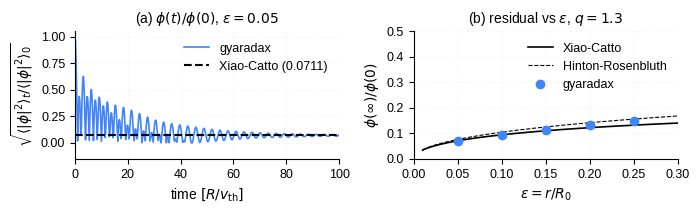

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.2))

# (a) Time trace
ax = axes[0]
ax.plot(time_trace, phi_ratio, "-", color=JAX_COLORS["blue"], lw=1.2, label="gyaradax")
ax.axhline(rh_residual_xiao_catto(q_rh, eps_rh), color="k", ls="--", lw=1.5,
           label=f"Xiao-Catto ({rh_residual_xiao_catto(q_rh, eps_rh):.4f})", zorder=10)
ax.set_xlabel(r"time $[R/v_{\mathrm{th}}]$")
ax.set_ylabel(r"$\sqrt{\langle|\phi|^2\rangle_t / \langle|\phi|^2\rangle_0}$")
ax.legend(frameon=False)
ax.set_xlim(0, time_trace[-1])
ax.set_ylim(-0.15, 1.05)
ax.grid(True)
ax.set_title(r"(a) $\phi(t)/\phi(0)$, $\varepsilon=0.05$")

# (b) Residual vs eps
eps_scan = np.linspace(0.01, 0.3, 100)
res_xc = np.array([rh_residual_xiao_catto(q_rh, e) for e in eps_scan])
res_hr = np.array([rh_residual_hinton(q_rh, e) for e in eps_scan])

ax2 = axes[1]
ax2.plot(eps_scan, res_xc, "-k", lw=1.2, label="Xiao-Catto")
ax2.plot(eps_scan, res_hr, "--k", lw=0.8, label="Hinton-Rosenbluth")
ax2.plot(eps_sim_vals, eps_sim_residuals, "o", color=JAX_COLORS["blue"], ms=6, zorder=5,
         label="gyaradax")
ax2.set_xlabel(r"$\varepsilon = r/R_0$")
ax2.set_ylabel(r"$\phi(\infty) / \phi(0)$")
ax2.legend(frameon=False)
ax2.set_xlim(0, 0.3)
ax2.set_ylim(0, 0.5)
ax2.grid(True)
ax2.set_title(r"(b) residual vs $\varepsilon$, $q=1.3$")

fig.tight_layout()
fig.savefig("figs/rh_zonal_flow.pdf")
plt.show()

---
## 2. CBC Linear ITG Growth Rate

The Cyclone Base Case (Dimitz et al., PoP 2000): $q=1.4$, $\hat{s}=0.78$, $\varepsilon=0.19$, $R/L_n=2.2$, $T_e/T_i=1$, electrostatic, adiabatic electrons, s-alpha geometry.

We reproduce two standard benchmarks from GKW (benchmarks.tex §1, Fig. 11.1):
- (a) Growth rate $\gamma$ vs $k_\theta\rho_s$ at fixed $R/L_T=6.9$
- (b) Peak growth rate vs $R/L_T$ at fixed $k_\theta\rho_s=0.5$

Parameters match the GKW benchmark (`gkw_ref/benchmarks/cyclone/linear`): $N_s=160$, $N_{v\parallel}=64$, $N_\mu=16$, `nperiod=5`, `disp_par=1.0`, `dt=0.003`, `naverage=100`.

In [41]:
# CBC linear ITG: scan ktheta*rho_s AND R/LT
# Uses GKW benchmark parameters from gkw_ref/benchmarks/cyclone/linear/

def run_cbc_linear(kt, rlt, n_windows=300):
    """Run single-mode CBC and return converged growth rate."""
    geom = compute_geometry(
        q=1.4, shat=0.78, eps=0.19,
        ns=160, nvpar=64, nmu=16, vpar_max=3.0,
        nkx=1, nky=1, nperiod=5,
        kxmax=kt, signB=1.0, Rref=1.0, krhomax=kt,
        geom_type="s-alpha",
    )
    params = GKParams(
        dt=0.003, naverage=100, non_linear=False, adaptive_dt=False,
        adiabatic_electrons=True,
        disp_par=1.0, disp_vp=0.0, disp_x=0.0, disp_y=0.0,
        finit="cosine2", amp_init=1e-4,
        mas=1.0, signz=1.0, tmp=1.0, de=1.0, vthrat=1.0,
        rlt=rlt, rln=2.2, dgrid=1.0, tgrid=1.0,
        sgr_dist=float(geom["sgr_dist"]), dvp=float(geom["dvp"]),
        kxmax=kt, kymax=kt, norm_eps=1e-14, drive_scale=1.0,
        idisp=2, cfl_safety=0.95,
    )
    df = init_f(geom, finit="cosine2", amp_init_real=1e-4)
    pre = linear_precompute(geom, params)
    state = default_state(nky=1)
    for _ in range(n_windows):
        df, phi, _, state = gk_run(df, geom, params, state, params.naverage, pre=pre)
    return float(state.last_growth_rate[0])

# (a) kt scan at R/LT=6.9
cbc_ktheta_vals = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
cbc_growth = []
for kt in cbc_ktheta_vals:
    gamma = run_cbc_linear(kt, rlt=6.9)
    cbc_growth.append(gamma)
    print(f"  kt={kt:.1f}: gamma={gamma:.4f}")
cbc_growth = np.array(cbc_growth)
cbc_ktheta_vals = np.array(cbc_ktheta_vals)

# (b) R/LT scan at kt=0.5
rlt_vals = [6.9, 8.28, 10.35, 12.44, 15.18]
rlt_growth = []
for rlt in rlt_vals:
    gamma = run_cbc_linear(kt=0.5, rlt=rlt)
    rlt_growth.append(gamma)
    print(f"  R/LT={rlt:.2f}: gamma={gamma:.4f}")
rlt_growth = np.array(rlt_growth)
rlt_vals = np.array(rlt_vals)

  kt=0.1: gamma=0.0360
  kt=0.2: gamma=0.0994
  kt=0.3: gamma=0.1556
  kt=0.4: gamma=0.1832
  kt=0.5: gamma=0.1787
  kt=0.6: gamma=0.1462
  kt=0.7: gamma=0.0935
  kt=0.8: gamma=0.0413
  R/LT=6.90: gamma=0.1787
  R/LT=8.28: gamma=0.2655
  R/LT=10.35: gamma=0.3806
  R/LT=12.44: gamma=0.4836
  R/LT=15.18: gamma=0.6040


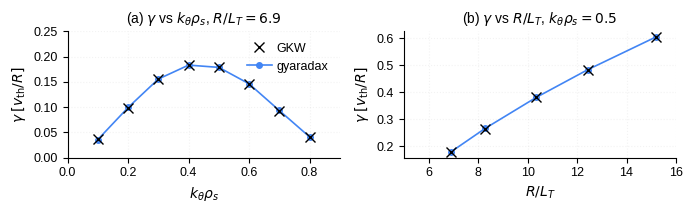

In [69]:
# Exact GKW reference values (run with identical parameters, ns=144, nperiod=5, METH=2)
gkw_cbc_kt =    np.array([0.1,    0.2,    0.3,    0.4,    0.5,    0.6,    0.7,    0.8])
gkw_cbc_gamma = np.array([0.0361, 0.0992, 0.1555, 0.1830, 0.1785, 0.1459, 0.0928, 0.0404])

# Exact GKW R/LT scan (run with identical parameters)
gkw_rlt_vals =  np.array([6.9,    8.28,   10.35,  12.44,  15.18])
gkw_rlt_gamma = np.array([0.1785, 0.2653, 0.3803, 0.4834, 0.6038])

fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.2))

# (a) growth rate vs kt
ax = axes[0]
ax.plot(gkw_cbc_kt, gkw_cbc_gamma, "x", color="k", ms=7, lw=1.8,
        markerfacecolor="none", label="GKW", zorder=4)
ax.plot(cbc_ktheta_vals, cbc_growth, "o-", color=JAX_COLORS["blue"], ms=4, lw=1.2,
        label="gyaradax")
ax.set_xlabel(r"$k_\theta \rho_s$")
ax.set_ylabel(r"$\gamma \; [v_{\mathrm{th}}/R]$")
ax.set_title(r"(a) $\gamma$ vs $k_\theta\rho_s$, $R/L_T=6.9$")
ax.legend(frameon=False, columnspacing=1.0, handletextpad=0.4)
ax.set_xlim(0, 0.9)
ax.set_ylim(0, 0.25)
ax.grid(True)

# (b) peak growth rate vs R/LT
ax2 = axes[1]
ax2.plot(gkw_rlt_vals, gkw_rlt_gamma, "x", color="k", ms=7, lw=1.8,
         markerfacecolor="none", label="GKW", zorder=4)
ax2.plot(rlt_vals, rlt_growth, "o-", color=JAX_COLORS["blue"], ms=4, lw=1.2,
         label="gyaradax")
ax2.set_xlabel(r"$R/L_T$")
ax2.set_ylabel(r"$\gamma \; [v_{\mathrm{th}}/R]$")
ax2.set_title(r"(b) $\gamma$ vs $R/L_T$, $k_\theta\rho_s=0.5$")
# ax2.legend(frameon=False, columnspacing=1.0, handletextpad=0.4)
ax2.set_xlim(5, 16)
ax2.grid(True)

fig.tight_layout()
fig.savefig("figs/cbc_linear_itg.pdf")
plt.show()